Описание задания:

В домашнем задании нужно улучшить метрики RMSE, R2 модели линейной регрессии путём работы с данными, а именно проведения разведочного анализа данных. В качестве датасета необходимо загрузить данные о недвижимости Калифорнии из библиотеки sklearn.datasets. Целевая переменная – `MedHouseVal`. Прочитать информацию о признаках датасета можно, выполнив следующий код – print(fetch_california_housing().DESCR).

Этапы работы:

- Получите данные и загрузите их в рабочую среду. (Jupyter Notebook или другую).
- Проверьте данные на наличие пропусков. Удалите их в случае обнаружения.
- Разделите выборку на обучающее и тестовое подмножества. 80% данных оставить на обучающее множество, 20% - на тестовое.
- Постройте модель линейной регрессии. Вычислите метрики RMSE, R2 на обучающем и тестовом множестве.
- Постройте график распределения целевой переменной. Сделайте вывод. Присутствуют ли в этом признаке выбросы?
- Посчитайте и выведите корреляционную матрицу. Убедитесь, что ячейки матрицы поделены на цветные категории, в ячейках указано числовое значение корреляции.
a. Сделайте выводы.
b. Удалите признаки на основании полученных значений, выводов.
c. Повторите п. 3, п. 4 на измененных данных.
- Исследуйте оставленные признаки на выбросы.
a. Удалите выбросы в случае обнаружения.
b. Повторите п. 3, п. 4 на измененных данных.
- Измените несколько признаков на выбор математически. Например, вычислите логарифм, возведите в квадрат, извлеките квадратный корень.
a. Повторите п. 3, п. 4 на измененных данных.
- Сформулируйте выводы по проделанной работе.
a. Кратко опишите какие преобразования были сделаны с данными.
b. Сравните метрики всех моделей. Желательно оформление в виде таблицы вида |модель|RMSE|R2|признаки, на которых проводилось обучение с указанием их преобразований|.
c. Напишите свое мнение, в полной ли мере модели справились с поставленной задачей.

Для получения зачета по этому домашнему заданию, минимально, должно быть реализовано обучение трех моделей классификации: на основе всех неизмененных признаков; на основе признаков, отобранных по значениям корреляций; на основе признаков, отобранных по значениям корреляций и с удалением выбросов в них. Должны быть выведены метрики RMSE, R2 моделей. Желательно добиться улучшения метрик.

от преподавателя:

Оставляю обратную связь по пунктам:

- С получением и считыванием данных всё отлично
- По пропускам так же
- По разбиению на трейн и тест замечательно
- Метрики считаете отлично
- Здорово, что искали выбросы через boxplot
- Еще можно было бы оставить только один из признаков AveRooms и AveBedrms, т.к. они очень коррелируют между собой, что может стать проблемой для линейной модели
- Провели очень хороший визуальный анализ
- С новыми признаками тоже всё отлично
- Можно было бы все результаты моделей свести в одну таблицу для большей наглядности

In [ ]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, r2_score

In [ ]:
data = fetch_california_housing()

In [ ]:
#data

In [ ]:
x = pd.DataFrame(data['data'], columns=data['feature_names'])
y = pd.Series(data['target'])
x.sample(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20591,1.4946,34.0,4.340694,1.186120,702.0,2.214511,39.15,-121.58
1794,3.2875,52.0,4.052632,0.868421,89.0,2.342105,37.94,-122.41
9666,2.0802,22.0,5.577682,1.128853,4276.0,2.636252,41.61,-120.55


In [ ]:
y.value_counts()

,count
5.00001,965
1.37500,122
1.62500,117
1.12500,103
1.87500,93
...,...
3.59200,1
0.54900,1
3.77600,1
0.81200,1


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


<Axes: >

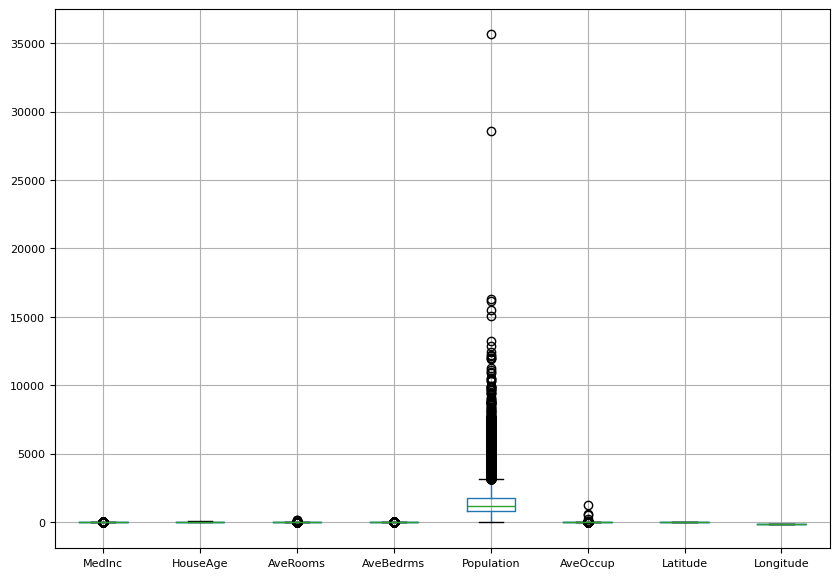

In [ ]:
plt.figure(figsize=(10,7))
x.boxplot(fontsize=8)

In [ ]:
x.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [ ]:
x.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


In [ ]:
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0)
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
pred_train = model.predict(x_train)
pred = model.predict(x_test)

In [ ]:
RMSE_train = root_mean_squared_error(y_train, pred_train)
RMSE = root_mean_squared_error(y_test, pred)
R2_train = r2_score(y_train, pred_train)
R2 = r2_score(y_test, pred)

print(f'Результат метрики RMSE train: {RMSE_train:.2f}')  # результат не очень, далеко от 0
print(f'Результат метрики RMSE test: {RMSE:.2f}')         # результат лучше, чем на train, но тоже далеко от 0
print(f'Результат метрики R2 train: {R2_train:.2f}')      # результат так себе, неблизко к 1
print(f'Результат метрики R2 test: {R2:.2f}')             # результат чуть хуже, чем у train, переобучения нет

Результат метрики RMSE train: 0.72
Результат метрики RMSE test: 0.73
Результат метрики R2 train: 0.61
Результат метрики R2 test: 0.59


<Axes: >

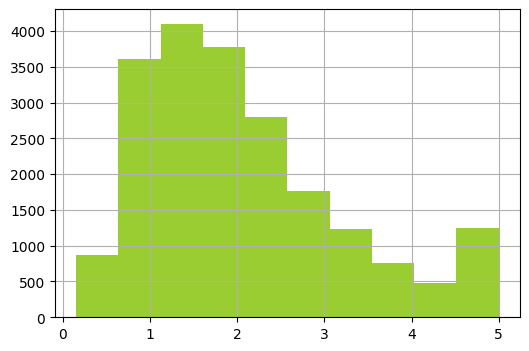

In [ ]:
plt.figure(figsize=(6, 4))
y.hist(color='yellowgreen')

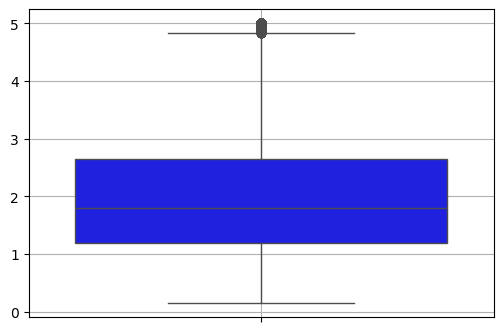

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y, color='b')
plt.grid()
plt.show()
# явно, что есть данные за границей, и можно это посмотреть через value_counts (выше есть)
# и там количество данных 5.00001 - 965 - большая группа выбросов сосредоточилась в этой точке

In [ ]:
x['MedHouseVal'] = data.target
x.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


<Axes: >

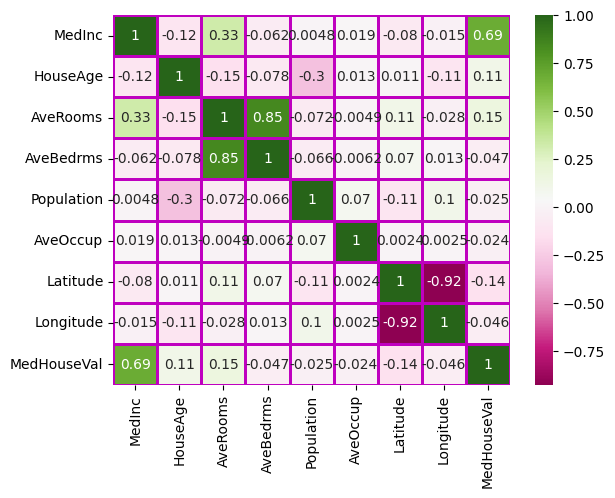

In [ ]:
sns.heatmap(x.corr(), annot = True, cmap= 'PiYG', linewidths=2, linecolor='m')
# мне кажется с корреляцией дело обстоит не очень: хорошая связь целевой с признаком MedInc,
# обратной связи почти нет с остальными признаками
# не уверена, что надо удалять почти все признаки
# можно попробовать удалить Population и AveOccup

In [ ]:
x.corr().style.background_gradient(cmap = 'viridis')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [ ]:
x.drop(['AveOccup',	'AveBedrms', 'Population', 'MedHouseVal'], axis=1, inplace=True)
x.head()

,MedInc,HouseAge,AveRooms,Latitude,Longitude
0,8.3252,41.0,6.984127,37.88,-122.23
1,8.3014,21.0,6.238137,37.86,-122.22
2,7.2574,52.0,8.288136,37.85,-122.24
3,5.6431,52.0,5.817352,37.85,-122.25
4,3.8462,52.0,6.281853,37.85,-122.25


In [ ]:
y.head()

,0
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
model2 = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=9)
model2.fit(x_train, y_train)

pred_train2 = model2.predict(x_train)
pred2 = model2.predict(x_test)

In [ ]:
RMSE_train2 = root_mean_squared_error(y_train, pred_train2)
RMSE2 = root_mean_squared_error(y_test, pred2)
R2_train2 = r2_score(y_train, pred_train2)
R2_2 = r2_score(y_test, pred2)

print(f'Результат метрики RMSE train: {RMSE_train2:.2f}')  # результат хуже
print(f'Результат метрики RMSE test: {RMSE2:.2f}')         # результат хуже
print(f'Результат метрики R2 train: {R2_train2:.2f}')      # результат хуже
print(f'Результат метрики R2 test: {R2_2:.2f}')            # результат тот же

# мне сложно сказать почему такие результаты, так как связь между удалёнными признаками и целевой почти отсутствует.

Результат метрики RMSE train: 0.73
Результат метрики RMSE test: 0.74
Результат метрики R2 train: 0.60
Результат метрики R2 test: 0.59


In [ ]:
x['MedHouseVal'] = data.target
x.head(3)

,MedInc,HouseAge,AveRooms,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,37.85,-122.24,3.521


<Axes: >

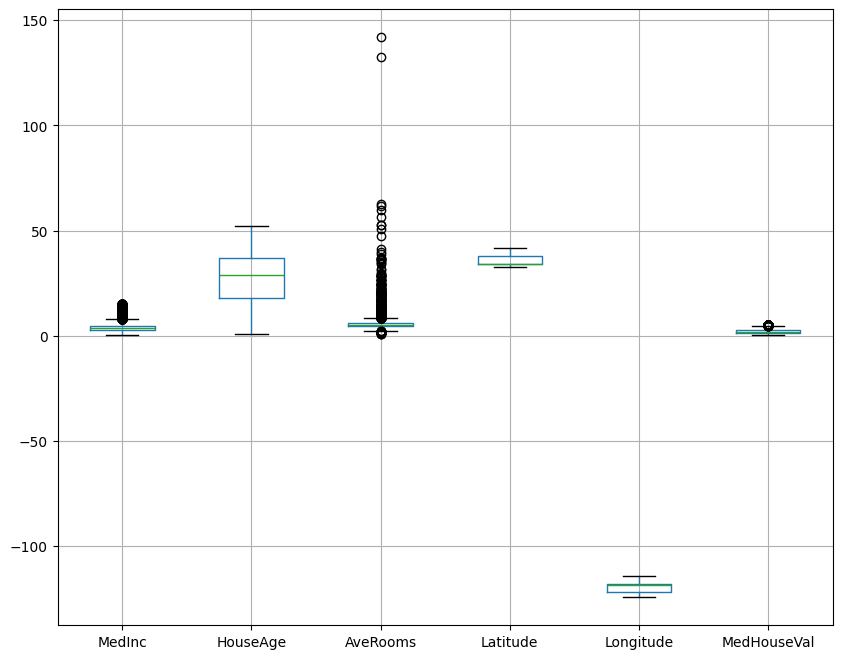

In [ ]:
plt.figure(figsize=(10, 8))
x.boxplot()

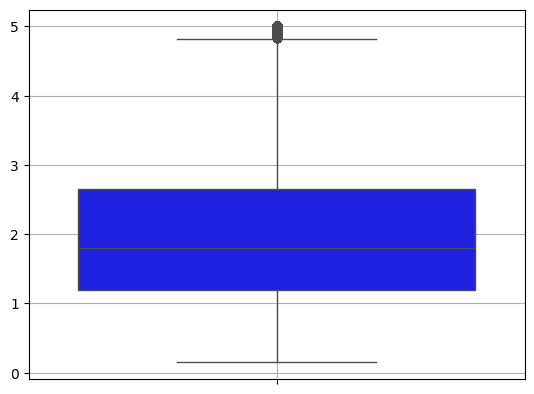

In [ ]:
sns.boxplot(y, color='b')
plt.grid()
plt.show()

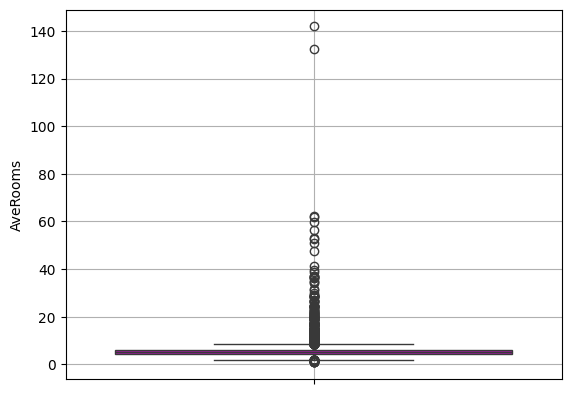

In [ ]:
sns.boxplot(x['AveRooms'], color='m')
plt.grid()
plt.show()

In [ ]:
x = x[(x['AveRooms'] < 8.3) & (x['AveRooms'] > 2.1)]

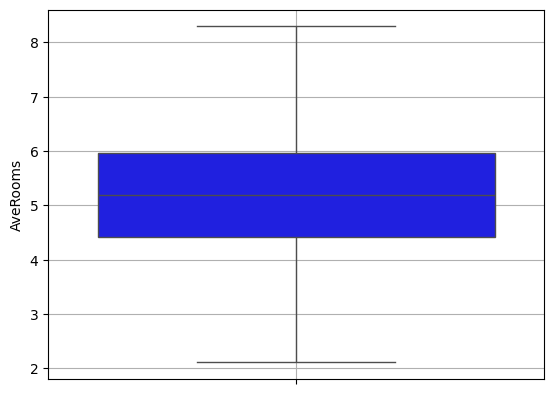

In [ ]:
sns.boxplot(x['AveRooms'], color='b')
plt.grid()
plt.show()

In [ ]:
# В описании есть инфо, что столбцы AveBedrms и AveRooms могут принимать неожиданно большие значения для групп блоков
# с небольшим количеством домохозяйств и большим количеством пустующих домов, таких как курорты.
# Но я всё-таки удалю выбросы, которые за границей, хочу посмотреть на метрику потом.

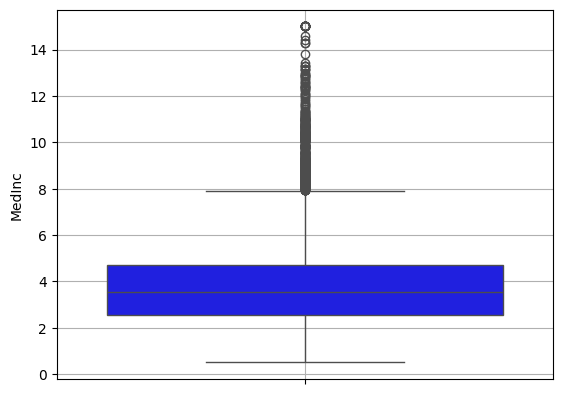

In [ ]:
sns.boxplot(x['MedInc'], color='b')
plt.grid()
plt.show()

In [ ]:
x = x[(x['MedInc'] < 7.5)]

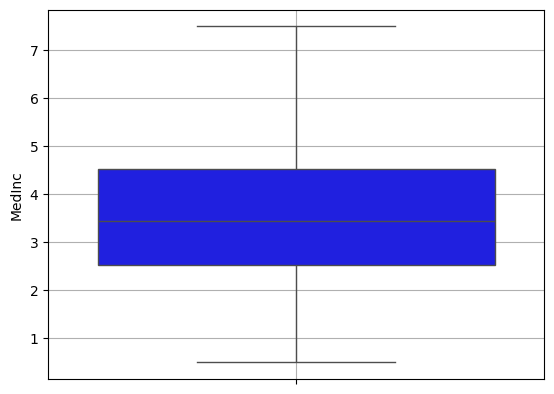

In [ ]:
sns.boxplot(x['MedInc'], color='b')
plt.grid()
plt.show()

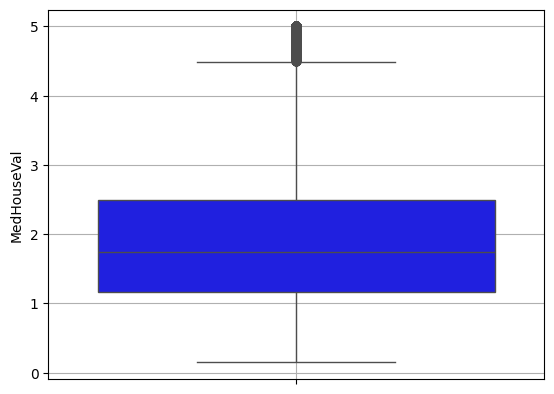

In [ ]:
sns.boxplot(x['MedHouseVal'], color='b')
plt.grid()
plt.show()

In [ ]:
x = x[(x['MedHouseVal'] < 4.2)]

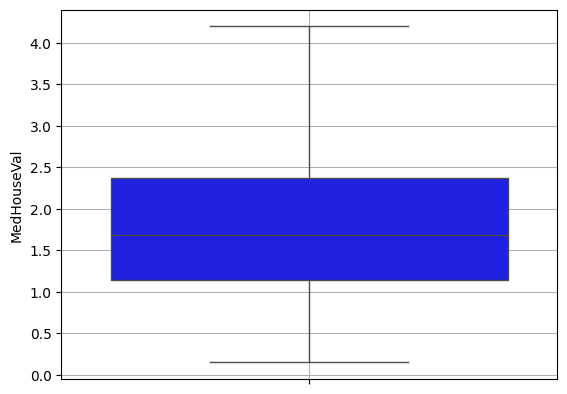

In [ ]:
sns.boxplot(x['MedHouseVal'], color='b')
plt.grid()
plt.show()

In [ ]:
x.head(1)

,MedInc,HouseAge,AveRooms,Latitude,Longitude,MedHouseVal
2,7.2574,52.0,8.288136,37.85,-122.24,3.521


In [ ]:
y = x['MedHouseVal']
y

,MedHouseVal
2,3.521
3,3.413
4,3.422
5,2.697
6,2.992
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
x.shape, y.shape

((18401, 6), (18401,))

In [ ]:
del x['MedHouseVal']

In [ ]:
x.shape, y.shape

((18401, 5), (18401,))

In [ ]:
model3 = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=7)
model3.fit(x_train, y_train)

pred_train3 = model3.predict(x_train)
pred3 = model3.predict(x_test)

In [ ]:
RMSE_train3 = root_mean_squared_error(y_train, pred_train3)
RMSE3 = root_mean_squared_error(y_test, pred3)
R2_train3 = r2_score(y_train, pred_train3)
R2_3 = r2_score(y_test, pred3)

print(f'Результат метрики RMSE train: {RMSE_train3:.2f}')  # результат лучше после удаления выбросов с 0.73 до 0.55
print(f'Результат метрики RMSE test: {RMSE3:.2f}')         # результат лучше с 0.74 до 0.55
print(f'Результат метрики R2 train: {R2_train3:.2f}')      # результат стал похуже с 0.60 до 0.56
print(f'Результат метрики R2 test: {R2_3:.2f}')            # результат чуть лучше с 0.59 до 0.56

Результат метрики RMSE train: 0.57
Результат метрики RMSE test: 0.57
Результат метрики R2 train: 0.56
Результат метрики R2 test: 0.56


In [ ]:
x['AveRooms'] = np.log(x['AveRooms'])
x['HouseAge'] = np.sqrt(x['HouseAge'])
x.head(2)

,MedInc,HouseAge,AveRooms,Latitude,Longitude
2,7.2574,7.211103,2.114825,37.85,-122.24
3,5.6431,7.211103,1.760845,37.85,-122.25


In [ ]:
model4 = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=5)
model4.fit(x_train, y_train)

pred_train4 = model4.predict(x_train)
pred4 = model4.predict(x_test)

In [ ]:
RMSE_train4 = root_mean_squared_error(y_train, pred_train4)
RMSE4 = root_mean_squared_error(y_test, pred4)
R2_train4 = r2_score(y_train, pred_train4)
R2_4 = r2_score(y_test, pred4)

print(f'Результат метрики RMSE train: {RMSE_train4:.2f}')  # результат лучше на 0.01
print(f'Результат метрики RMSE test: {RMSE4:.2f}')         # результат хуже на 0.01
print(f'Результат метрики R2 train: {R2_train4:.2f}')      # результат тот же
print(f'Результат метрики R2 test: {R2_4:.2f}')            # результат тот же

Результат метрики RMSE train: 0.56
Результат метрики RMSE test: 0.58
Результат метрики R2 train: 0.56
Результат метрики R2 test: 0.56


'Результат метрики RMSE train: 0.56\nРезультат метрики RMSE test: 0.58\nРезультат метрики R2 train: 0.56\nРезультат метрики R2 test: 0.56'

In [ ]:
# после всех манипуляций результат RMSE улучшился с 0.73 и 0.71 (тест) до 0.55
# а вот метрика R2 ухудшилась с 0.60 и 0.62 (тест) до 0.58
# большой разницы между трейнинговыми результатами и тестовыми не наблюдалось.

# Вывод - манипуляции с удалением выбросов и удалением признаков, у которых почти не корреляции
# с целевой переменной + математические операции с признаками улучшили
# только метрику rmse, но ухудшили коэффициент детерминации. Возможно, надо пробовать ещё,
# удаляя другие признаки и применяя другие мат.операции

In [ ]:
res = pd.DataFrame()
res['Res_1'] = [RMSE_train, RMSE, R2_train, R2]
res['Res_2'] = [RMSE_train2, RMSE2, R2_train2, R2_2]
res['Res_3'] = [RMSE_train3, RMSE3, R2_train3, R2_3]
res['Res_4'] = [RMSE_train4, RMSE4, R2_train4, R2_4]

In [ ]:
res['Index'] = ['RMSE_train', 'RMSE', 'R2_train', 'R2']

In [ ]:
res = res.set_index('Index')

In [ ]:
res

,Res_1,Res_2,Res_3,Res_4
Index,,,,
RMSE_train,0.723492,0.732156,0.568720,0.564253
RMSE,0.727313,0.742781,0.565267,0.575016
R2_train,0.608897,0.596524,0.558741,0.561143
R2,0.594323,0.589271,0.557140,0.560090
